In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.datasets import fetch_datasets
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from sklearn.model_selection import train_test_split, cross_validate

In [2]:
import warnings
warnings.filterwarnings("ignore", message="lbfgs failed to converge after")

## Load dataset

In [3]:
# Load dataset from imbalanced-learn.
def load_dataset(dataset):
    
    data = fetch_datasets()[dataset]
    data.target = np.where(data.target < 0, 0, 1)
    X, y = data.data, data.target
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0)
    
    return X_train, X_test, y_train, y_test

In [4]:
X_train, X_test, y_train, y_test = load_dataset("protein_homo")

print(f"Target mean: {np.mean(y_train):.4f}")

Target mean: 0.0087


## Select model with cross-validation

In [5]:
# Machine learning models to train:

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "GBM":                 GradientBoostingClassifier(random_state=42),
}

scoring = ["roc_auc", "average_precision"]

all_results = {}

for name, model in models.items():
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=3,
        scoring=scoring,
        n_jobs=-1,
    )
    # Each model contributes a (metric → mean/std) block
    all_results[name] = pd.DataFrame(cv_results).agg(["mean", "std"]).T

# Concatenate along columns with model name as top-level key
results_df = pd.concat(all_results, axis=1)
results_df

Logistic Regression           Random Forest            \
                                      mean       std          mean       std   
fit_time                         42.384828  0.082351     30.603358  0.464740   
score_time                        0.020895  0.005377      0.116383  0.004341   
test_roc_auc                      0.989333  0.001335      0.967317  0.004421   
test_average_precision            0.858893  0.008506      0.847698  0.003526   

                              GBM            
                             mean       std  
fit_time                71.314603  0.044559  
score_time               0.029228  0.001709  
test_roc_auc             0.986149  0.000752  
test_average_precision   0.784261  0.054633

In [6]:
def evaluate_model_on_test_set(model, X, y):
    # To obtain a dispersion value, we take 
    # bootstrap samples of the test set.
    X = np.asarray(X)
    y = np.asarray(y)
    n = int(0.6 * len(X))

    roc_auc = []
    ap = []

    for seed in range(1, 6):
        idx = np.random.default_rng(seed).choice(len(X), size=n, replace=True)
        xs, ys = X[idx], y[idx]
        prob = model.predict_proba(xs)[:, 1]

        roc_auc.append(roc_auc_score(ys, prob))
        ap.append(average_precision_score(ys, prob))

    return np.mean(roc_auc), np.std(roc_auc), np.mean(ap), np.std(ap)

In [7]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)

    roc_mean, roc_std, ap_mean, ap_std = evaluate_model_on_test_set(model, X_test, y_test)

    results[name] = {
        "roc_auc_mean": roc_mean,
        "roc_auc_std": roc_std,
        "ap_mean": ap_mean,
        "ap_std": ap_std,        
    }

pd.DataFrame(results)

,Logistic Regression,Random Forest,GBM
roc_auc_mean,0.992319,0.982446,0.986060
roc_auc_std,0.002485,0.003354,0.004365
ap_mean,0.881471,0.885058,0.831094
ap_std,0.020861,0.019085,0.023326


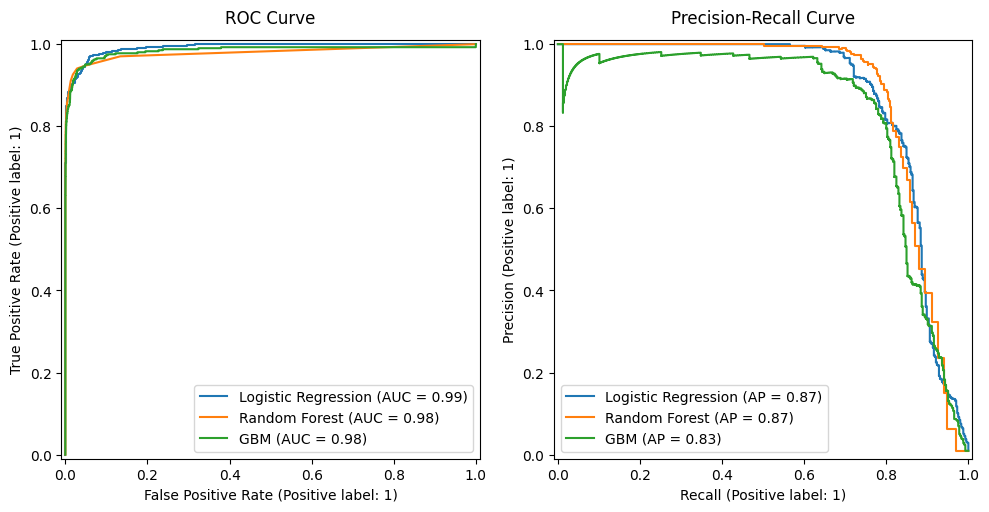

In [8]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for name, model in models.items():
    y_test_proba = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_test_proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, name=name, ax=axes[1])

axes[0].set_title("ROC Curve", y=1.02)
axes[1].set_title("Precision-Recall Curve", y=1.02)

plt.tight_layout()
plt.savefig("../../mlid-book/resources/ch2/ch2-fig19.png", dpi=150)
plt.show()

## Hyperparameter optimisation

We use successive halving to speed up the optimisation process.

In [9]:
from scipy import stats
from sklearn.model_selection import HalvingRandomSearchCV

gbm = models["GBM"]

params = {
    "max_depth": (1, 2, 3, 4, 8, None),
    "learning_rate": stats.uniform(0, 1),
    "min_samples_split": stats.randint(2, 20),
    "max_features": ("log2", 0.25, "sqrt", 1.0),
    "subsample": stats.uniform(0, 1),
}

search = HalvingRandomSearchCV(
    estimator=gbm,
    param_distributions=params,
    n_candidates="exhaust",  # the number of candidates to evaluate at the first iteration
    factor=3,  # only a third of the candidates are promoted
    resource="n_estimators",  # the limiting resource
    max_resources=500, # max number of trees (or samples)
    min_resources=10,  # min number of trees (or samples)
    scoring="roc_auc",
    cv=3,  # uses StratifiedKFold by default
    random_state=10,
    refit=True,
    n_jobs=-1,
)

search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....t 0x1136f7b60>, 'max_depth': (1, ...), 'max_features': ('log2', ...), 'min_samples_split': <scipy.stats....t 0x1136f7cb0>, ...}"
,"n_candidates n_candidates: ""exhaust"" or int, default=""exhaust""The number of candidate parameters to sample, at the firstiteration. Using 'exhaust' will sample enough candidates so that thelast iteration uses as many resources as possible, based on`min_resources`, `max_resources` and `factor`. In this case,`min_resources` cannot be 'exhaust'.",'exhaust'
,"factor factor: int or float, default=3The 'halving' parameter, which determines the proportion of candidatesthat are selected for each subsequent iteration. For example,``factor=3`` means that only one third of the candidates are selected.",3
,"resource resource: ``'n_samples'`` or str, default='n_samples'Defines the resource that increases with each iteration. By default,the resource is the number of samples. It can also be set to anyparameter of the base estimator that accepts positive integervalues, e.g. 'n_iterations' or 'n_estimators' for a gradientboosting estimator. In this case ``max_resources`` cannot be 'auto'and must be set explicitly.",'n_estimators'
,"max_resources max_resources: int, default='auto'The maximum number of resources that any candidate is allowed to usefor a given iteration. By default, this is set ``n_samples`` when``resource='n_samples'`` (default), else an error is raised.",500
,"min_resources min_resources: {'exhaust', 'smallest'} or int, default='smallest'The minimum amount of resource that any candidate is allowed to usefor a given iteration. Equivalently, this defines the amount ofresources `r0` that are allocated for each candidate at the firstiteration.- 'smallest' is a heuristic that sets `r0` to a small value: - ``n_splits * 2`` when ``resource='n_samples'`` for a regression problem - ``n_classes * n_splits * 2`` when ``resource='n_samples'`` for a classification problem - ``1`` when ``resource != 'n_samples'``- 'exhaust' will set `r0` such that the **last** iteration uses as much resources as possible. Namely, the last iteration will use the highest value smaller than ``max_resources`` that is a multiple of both ``min_resources`` and ``factor``. In general, using 'exhaust' leads to a more accurate estimator, but is slightly more time consuming. 'exhaust' isn't available when `n_candidates='exhaust'`.Note that the amount of resources used at each iteration is always amultiple of ``min_resources``.",10
,"aggressive_elimination aggressive_elimination: bool, default=FalseThis is only relevant in cases where there isn't enough resources toreduce the remaining candidates to at most `factor` after the lastiteration. If ``True``, then the search process will 'replay' thefirst iteration for as long as needed until the number of candidatesis small enough. This is ``False`` by default, which means that thelast iteration may evaluate more than ``factor`` candidates. See:ref:`aggressive_elimination` for more details.",False
,"cv cv: int, cross-validation generator or an iterable, default=5Determines the cross-validation splitting strategy.Possible inputs for cv are:- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if t

In [10]:
search.best_estimator_

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",np.float64(0....1665387269341)
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",270
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",np.float64(0.9177741225129434)
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",19
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",8
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is th

In [11]:
search.best_score_

np.float64(0.9898319928349789)

In [12]:
pd.DataFrame(search.cv_results_)

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_max_features,param_min_samples_split,...,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,0,10,13.780978,0.035572,0.014680,0.002360,0.771321,8,1.0,2,...,0.842538,0.708746,0.702343,0.117170,65,0.573318,0.876694,0.734134,0.728049,0.123927
1,0,10,14.396330,0.237218,0.073670,0.004756,0.831911,None,log2,19,...,0.745382,0.806124,0.775132,0.024814,57,0.918425,0.879975,0.897098,0.898499,0.015728
2,0,10,0.714758,0.023870,0.017359,0.003177,0.265566,3,log2,6,...,0.844170,0.915036,0.899149,0.040013,27,0.957310,0.851911,0.933308,0.914176,0.045106
3,0,10,0.419825,0.036795,0.013351,0.005342,0.816602,4,sqrt,13,...,0.558748,0.587129,0.673940,0.143307,67,0.885926,0.601281,0.556204,0.681137,0.145972
4,0,10,3.381721,0.040773,0.019583,0.006770,0.030617,8,sqrt,19,...,0.978726,0.969883,0.974114,0.003621,6,0.981720,0.984798,0.981773,0.982764,0.001439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2,90,4.357302,0.062410,0.057589,0.019057,0.011788,4,log2,12,...,0.969863,0.968646,0.970304,0.001564,8,0.980533,0.977624,0.976404,0.978187,0.001732
71,2,90,67.894046,0.710350,0.024383,0.004490,0.068097,4,1.0,9,...,0.979317,0.970053,0.978297,0.006355,4,0.994510,0.997089,0.993045,0.994881,0.001672
72,2,90,21.839288,0.441013,0.050380,0.004999,0.030617,8,sqrt,19,...,0.986238,0.984750,0.985646,0.000645,2,0.998326,0.999093,0.999006,0.998809,0.000343
73,3,270,191.826350,0.284608,0.049630,0.003103,0.068097,4,1.0,9,...,0.984751,0.971023,0.975749,0.006368,5,0.999970,0.999990,0.996646,0.998868,0.001572


In [13]:
search.n_candidates_

[50, 17, 6, 2]